# MovieLens 100K — Audience Segmentation and Genre Affinity

**Objective.** Develop interpretable behavioral audience segments for a hypothetical streaming platform, measure genre affinity, and identify possible lookalike audiences for content and marketing hypotheses.

**Selected solution.** Four K-means segments based on standardized log rating activity and mean user rating. Genre behavior is used after clustering for interpretation rather than being forced into the final distance function.

**Central limitation.** MovieLens records explicit ratings, not verified views, impressions, completion, watch time, campaign exposure, churn, or retention. Throughout this notebook, “engagement” means **rating activity proxy**. Recommendations are hypotheses to test—not causal or predictive claims.

The notebook is the narrative layer. Reusable transformations live in `src/`, and every stage is followed by an independent validator that reloads written artifacts and fails on broken assumptions.

## 0. Reproducible setup

**Decision.** Keep implementation in importable modules and use this notebook to show questions, evidence, choices, validation, and interpretation.

**Reason.** This avoids duplicated notebook logic and makes the same analysis runnable through `python run_pipeline.py`.

In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
from IPython.display import Image, display

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/movielens-audience-analytics-mpl")

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the project directory or its notebooks directory.")
sys.path.insert(0, str(ROOT))

from src.affinity import calculate_affinity
from src.config import ProjectPaths
from src.data_prep import prepare_data
from src.feature_engineering import build_user_features
from src.reporting import create_dashboard_exports, create_figures
from src.segmentation import fit_final_segments, run_segmentation_experiments
from src.validation import (
    validate_affinity,
    validate_all,
    validate_dashboard,
    validate_experiments,
    validate_features,
    validate_final_segments,
    validate_processed,
    validate_raw,
)

paths = ProjectPaths(ROOT)
paths.ensure_output_directories()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print("Portable project setup complete")

Portable project setup complete


## 1. Business question and analytical contract

### Question

Can users be grouped into stable, meaningful behavioral audiences that help content and marketing teams form differentiated targeting hypotheses?

### What “actionable” means here

- A segment is sufficiently large and stable to describe consistently.
- Its behavior or affinity differs in a way that suggests a distinct campaign, recommendation, or research hypothesis.
- Every opportunity includes enough metric context to avoid mistaking relative lift for absolute scale.

### What this analysis cannot answer

- Whether a campaign will improve retention or acquisition.
- Whether high ratings cause repeat viewing.
- Whether low ratings combined with repeated genre activity reflect loyalty, dissatisfaction, limited alternatives, or exposure effects.

Those questions require watch behavior, impressions, experimentation, and outcome labels that are absent here.

## 2. Ingest and audit the full source

### Question

Which files are canonical, how do they connect, and which source irregularities actually require transformation?

### Decisions before code

- Use `u.data` as the canonical 100,000-rating table; the base/test files are overlapping predefined splits.
- Join on `user_id` and `movie_id`, never title text.
- Preserve missing or unusual source values unless they prevent the analysis.
- Retain demographics for descriptive audit only, not cluster formation.

In [2]:
raw_validation = validate_raw(paths)
raw_inventory = pd.DataFrame(
    {
        "file": sorted(path.name for path in paths.raw.iterdir() if path.is_file()),
    }
)
raw_inventory["bytes"] = raw_inventory["file"].map(lambda name: (paths.raw / name).stat().st_size)
print("Raw-data validation checks (all must pass before ingestion):")
display(pd.DataFrame([raw_validation["checks"]]).T.rename(columns={0: "passed"}))
print("\nRaw file inventory:")
display(raw_inventory)

Raw-data validation checks (all must pass before ingestion):


,passed
raw_file_present_u.data,True
raw_file_present_u.user,True
raw_file_present_u.item,True
raw_file_present_u.genre,True
raw_file_present_u.info,True
raw_file_present_README,True
u_data_has_100000_rows,True
u_user_has_943_rows,True
u_item_has_1682_rows,True



Raw file inventory:


,file,bytes
0,README,6750
1,u.data,1979173
2,u.genre,202
3,u.info,36
4,u.item,236344
5,u.user,22628


In [3]:
tables = prepare_data(paths)
processed_validation = validate_processed(paths)
profile = json.loads((paths.processed / "data_profile.json").read_text())
decisions = pd.DataFrame(json.loads((paths.processed / "cleaning_decisions.json").read_text()))

print("Data profile (source-level facts and integrity counts):")
display(pd.Series(profile, name="value").to_frame())
print("\nCleaning decisions and their rationale:")
display(decisions)
print("\nProcessed-data validation checks (integrity, uniqueness, ranges, joins):")
display(pd.DataFrame([processed_validation["checks"]]).T.rename(columns={0: "passed"}))

Data profile (source-level facts and integrity counts):


,value
source,MovieLens 100K
source_url,https://files.grouplens.org/datasets/movielens...
source_readme_sha256,4883b8cf340ed0059971b33f56ad3adc88a40792108ebc...
rows,"{'ratings': 100000, 'users': 943, 'movies': 1682}"
rating_period_utc,"[1997-09-20T03:05:10+00:00, 1998-04-22T23:10:3..."
missing_release_dates,1
duplicate_movie_title_rows,36
release_title_year_mismatches,190
movies_without_known_genre,2
matrix_density,0.0630



Cleaning decisions and their rationale:


,decision,reason,effect
0,Use u.data as the canonical ratings table,The supplied base/test files are overlapping p...,The analytical population contains exactly 100...
1,Retain all 943 users,Every user has at least 20 ratings; unusual ac...,Outliers are flagged and tested through sensit...
2,"Treat ratings as rating activity, not confirme...","The data contains no starts, watch time, compl...",Engagement and campaign conclusions are framed...
3,Exclude demographics from clustering,"The business question is behavioral, and demog...","Age, gender, occupation, and ZIP code remain a..."
4,Preserve movie IDs even when titles repeat,The source identifies catalog records by movie...,Potential title duplicates remain reviewable w...
5,"Use timestamps descriptively, not as viewing c...",Many histories were submitted in compressed ba...,"No recency, session, or retention claim is bas..."



Processed-data validation checks (integrity, uniqueness, ranges, joins):


,passed
ratings_row_count,True
users_row_count,True
movies_row_count,True
rating_user_movie_key_unique,True
user_key_unique,True
movie_key_unique,True
ratings_valid,True
all_users_joined,True
all_movies_joined,True
genre_bridge_matches_flags,True


### Evidence and resulting cleaning decision

The canonical tables have complete rating-to-user and rating-to-movie joins. Ratings are already unique at the user–movie grain and lie on the documented 1–5 scale. Therefore, “cleaning” is primarily schema enforcement, date parsing, auditable derived fields, and a long movie–genre bridge—not aggressive row deletion.

One release date is missing and two records use the source `unknown` genre flag. These records remain valid for the behavioral model; unsupported imputation would add more assumption than information.

**Next decision.** Which compact user features are justified by the business question and data quality?

## 3. Focused exploratory analysis

EDA is limited to evidence that affects feature or modeling choices:

- User activity distribution and long-tail behavior
- User rating tendency and variability
- Genre prevalence and multi-label structure
- Potentially unusual users
- Sparsity of the user–movie matrix

Timestamps are not used for recency features because many histories appear batch-submitted and are not reliable universal viewing chronology.

In [4]:
activity = tables["user_activity"]
eda_summary = pd.DataFrame(
    {
        "metric": [
            "Users",
            "Ratings",
            "Movies",
            "Median ratings per user",
            "95th percentile ratings per user",
            "Mean rating",
            "User–movie matrix density",
        ],
        "value": [
            len(tables["users"]),
            len(tables["ratings"]),
            len(tables["movies"]),
            activity["rating_count"].median(),
            activity["rating_count"].quantile(0.95),
            tables["ratings"]["rating"].mean(),
            profile["matrix_density"],
        ],
    }
)
print("Dataset-level EDA summary:")
display(eda_summary)
print("\nTop genres by rating memberships:")
display(tables["genre_summary"].head(10))

# Evidence for the mean/median redundancy exclusion: rather than assert that a
# per-user median rating duplicates the mean, measure it directly.
per_user_rating = (
    tables["ratings"].groupby("user_id")["rating"].agg(["mean", "median"]).dropna()
)
print(
    f"\nPer-user mean vs. median rating correlation: "
    f"{per_user_rating['mean'].corr(per_user_rating['median']):.3f} "
    f"(high correlation confirms median adds little beyond mean, supporting its exclusion)."
)

Dataset-level EDA summary:


,metric,value
0,Users,943.0000
1,Ratings,"100,000.0000"
2,Movies,"1,682.0000"
3,Median ratings per user,65.0000
4,95th percentile ratings per user,310.6000
5,Mean rating,3.5299
6,User–movie matrix density,0.0630



Top genres by rating memberships:


,genre,rating_memberships,users,movies,mean_rating
7,Drama,39895,943,725,3.6874
4,Comedy,29832,940,505,3.3941
0,Action,25589,938,251,3.4802
15,Thriller,21872,937,251,3.5090
13,Romance,19461,943,247,3.6217
1,Adventure,13753,901,135,3.5035
14,Sci-Fi,12730,908,101,3.5607
16,War,9398,925,71,3.8158
5,Crime,8055,914,109,3.6323
3,Children's,7182,805,122,3.3532



Per-user mean vs. median rating correlation: 0.860 (high correlation confirms median adds little beyond mean, supporting its exclusion).


## 4. Minimal feature engineering

### Candidate feature families

1. **Activity:** `log(1 + rating_count)`
2. **Rating behavior:** mean rating and rating standard deviation
3. **Content composition:** 18 fractional genre shares

### Fractional genre rule

If a title has three genres, one rating contributes one-third to each genre. This prevents a multi-genre title from creating three full interaction events.

### Explicit exclusions

Median plus mean, entropy plus standard deviation, and raw plus transformed activity would repeat similar information. Genre lift is a post-segmentation population comparison and is not a distinct user-level clustering signal. Demographics are excluded from model inputs.

In [5]:
features = build_user_features(paths)
feature_validation = validate_features(paths)
feature_dictionary = pd.read_csv(paths.model / "feature_dictionary.csv")
feature_exclusions = pd.read_csv(paths.model / "feature_exclusions.csv")
outlier_thresholds = pd.read_csv(paths.model / "outlier_thresholds.csv")

print("Feature dictionary (each retained feature and why it is included):")
display(feature_dictionary)
print("\nExplicitly excluded features and the reason for exclusion:")
display(feature_exclusions)
print("\nIQR outlier thresholds per feature:")
display(outlier_thresholds)
print("\nFeature validation checks:")
display(pd.DataFrame([feature_validation["checks"]]).T.rename(columns={0: "passed"}))

Feature dictionary (each retained feature and why it is included):


,feature,category,definition,reason_included
0,log_rating_count,activity,Natural log of one plus the user's rating-even...,Represents activity while reducing long-tail l...
1,mean_rating,rating behavior,User's mean rating on the source 1–5 scale.,Separates generally critical from generally po...
2,rating_std,rating behavior,Within-user sample standard deviation of ratings.,Candidate selectivity measure; tested but not ...
3,genre_share_*,content behavior,User's fractional rating activity assigned to ...,Tests whether genre composition improves segme...



Explicitly excluded features and the reason for exclusion:


,excluded_feature,reason
0,median_rating,Overlaps strongly with mean rating and adds co...
1,rating_entropy,Another rating-spread transformation; rating s...
2,demographics,Reserved for descriptive audit; behavioral seg...
3,engagement_lift,Population-relative derivative of genre share;...
4,timestamp recency,Rating timestamps are often batch-submission t...



IQR outlier thresholds per feature:


,feature,q1,q3,iqr,lower_bound,upper_bound,flagged_users
0,log_rating_count,3.5264,5.0039,1.4776,1.3100,7.2203,0
1,mean_rating,3.3231,3.8696,0.5465,2.5033,4.6893,17
2,rating_std,0.8760,1.1399,0.2639,0.4801,1.5358,12



Feature validation checks:


,passed
one_row_per_user,True
expected_genre_features,True
no_model_feature_missingness,True
rating_counts_at_least_20,True
genre_shares_nonnegative,True
genre_share_total_at_most_one,True
outlier_flag_boolean,True


### Outlier decision

The IQR rule is chosen over a z-score rule deliberately: user activity is strongly right-skewed (the reason `log(1 + rating_count)` is used for distance modeling), and a z-score assumes an approximately normal distribution, so it would misplace thresholds on skewed data. The IQR rule is distribution-agnostic and robust to that skew.

IQR flags identify behavioral extremes, not data errors. Removing them by default would erase exactly the heavy or unusual users a segmentation may need to describe. The final population therefore retains them, while the experiment matrix includes a separate outlier-excluded sensitivity population.

**Next decision.** Which feature family and number of clusters produce the best combination of structure, stability, meaningful sizes, and interpretability?

## 5. Segmentation experiment and validation design

### Why unsupervised learning?

No churn, campaign-response, conversion, or retention label exists. A supervised model would require inventing a target. Clustering is used to summarize current behavior, not predict an outcome.

### Why K-means as the baseline?

K-means is reproducible, scalable, understandable for standardized numeric inputs, and operationally convenient because new users can be assigned to centroids. Its limitations are important: it favors convex structure, depends on scaling, and creates hard boundaries.

### Experiment matrix

- 2 populations: all users and IQR-flagged users excluded
- 5 declared feature sets
- K from 3 through 8
- **60 configurations total**

### Validation for every configuration

- Silhouette, Calinski–Harabasz, and Davies–Bouldin structure metrics
- Ten single-initialization stability comparisons using Adjusted Rand Index
- Two repetitions of ten-fold whole-user validation
- Each fold holds out approximately 10% of complete users and balances activity quintiles
- Held-out distance, assignment margin, minimum cluster share, and ARI versus the full-data reference

This is a stability/generalization diagnostic for unseen users—not predictive accuracy.

In [6]:
experiments = run_segmentation_experiments(paths)
experiment_validation = validate_experiments(paths)
display(pd.DataFrame([experiment_validation["checks"]]).T.rename(columns={0: "passed"}))

comparison_columns = [
    "population",
    "feature_set",
    "k",
    "silhouette",
    "seed_ari_mean",
    "cv_reference_ari_mean",
    "cv_heldout_distance_ratio_mean",
    "smallest_cluster_share",
]
display(
    experiments.loc[experiments["smallest_cluster_share"].ge(0.05), comparison_columns]
    .sort_values(["silhouette", "cv_reference_ari_mean"], ascending=False)
    .head(15)
)

,passed
expected_60_experiments,True
experiment_key_unique,True
all_k_values_present,True
silhouette_range,True
ari_range,True
positive_distance_ratio,True
nonempty_clusters,True


,population,feature_set,k,silhouette,seed_ari_mean,cv_reference_ari_mean,cv_heldout_distance_ratio_mean,smallest_cluster_share
24,all_users,E_behavior_minimal,3,0.3809,0.9262,0.9468,1.0066,0.2471
54,iqr_outliers_excluded,E_behavior_minimal,3,0.3797,0.9381,0.9360,1.0078,0.2508
55,iqr_outliers_excluded,E_behavior_minimal,4,0.3642,0.8473,0.9587,1.0093,0.1941
25,all_users,E_behavior_minimal,4,0.3584,0.7819,0.9545,1.0083,0.1718
56,iqr_outliers_excluded,E_behavior_minimal,5,0.3558,0.9577,0.9546,1.0080,0.1461
58,iqr_outliers_excluded,E_behavior_minimal,7,0.3518,0.8674,0.9576,1.0122,0.0905
57,iqr_outliers_excluded,E_behavior_minimal,6,0.3474,0.6892,0.8810,1.0114,0.1210
28,all_users,E_behavior_minimal,7,0.3462,0.8715,0.8681,1.0215,0.0795
26,all_users,E_behavior_minimal,5,0.3449,0.9279,0.9232,1.0107,0.1379
59,iqr_outliers_excluded,E_behavior_minimal,8,0.3422,0.7748,0.8355,1.0186,0.0851


## 6. Final model decision: K=4 with minimal behavioral features

The genre-inclusive models add dimensions but reduce separation. Genre is more useful as an explanatory overlay than as the primary creator of clusters in this dataset. Keeping genre downstream also avoids circularity: if genre helped form the segments, then per-segment genre affinity would partly restate the features that created them, rather than describing the audiences independently.

K=3 is the statistical parsimony benchmark and has a slightly stronger silhouette. K=4 is selected for the final project because:

- It retains strong whole-user fold stability (ARI approximately 0.95).
- Its single-start stability is lower than K=3, so the final model uses 50 starts and reports that sensitivity explicitly.
- Every segment remains large enough for audience-level action.
- It separates high-activity users into critical and positive rating styles.
- That split offers a distinct campaign and recommendation hypothesis that K=3 combines.

This is a transparent business-versus-parsimony tradeoff, not a claim that four natural populations objectively exist.

In [7]:
assignments, segment_summary = fit_final_segments(paths)
segment_validation = validate_final_segments(paths)
k_decision = pd.read_csv(paths.model / "k3_k4_decision.csv")
centers = pd.read_csv(paths.model / "final_cluster_centers.csv")

display(k_decision)
display(centers)
display(segment_summary)
display(pd.DataFrame([segment_validation["checks"]]).T.rename(columns={0: "passed"}))

,k,silhouette,seed_ari_mean,cv_reference_ari_mean,smallest_cluster_share,cv_heldout_distance_ratio_mean,selected,decision_note
0,3,0.3809,0.9262,0.9468,0.2471,1.0066,False,Statistical baseline: slightly higher silhouet...
1,4,0.3584,0.7819,0.9545,0.1718,1.0083,True,Selected: strong user-fold stability and actio...


,raw_cluster,segment,segment_name,log_rating_count_center,mean_rating_center
0,1,S1,Heavy Critics,5.2872,3.1444
1,0,S2,Casual Critics,3.5661,3.2107
2,2,S3,Heavy Enthusiasts,5.0239,3.7988
3,3,S4,Casual Enthusiasts,3.6629,3.9505


,segment,segment_name,user_count,median_rating_count,mean_rating_count,mean_user_rating,mean_rating_variability,median_assignment_margin,boundary_user_count_margin_lt_0_20,boundary_user_count_margin_lt_0_30,outlier_user_count,user_share,boundary_user_share_margin_lt_0_20,boundary_user_share_margin_lt_0_30,outlier_user_share
0,S1,Heavy Critics,162,192.5000,222.1235,3.1444,1.0689,0.4800,21,46,6,0.1718,0.1296,0.2840,0.0370
1,S2,Casual Critics,232,31.5000,37.6379,3.2107,1.1079,0.5325,36,58,12,0.2460,0.1552,0.2500,0.0517
2,S3,Heavy Enthusiasts,260,144.0000,167.2654,3.7988,0.9879,0.4882,43,75,2,0.2757,0.1654,0.2885,0.0077
3,S4,Casual Enthusiasts,289,38.0000,40.8131,3.9505,0.9505,0.5421,37,62,6,0.3065,0.1280,0.2145,0.0208


,passed
one_assignment_per_user,True
four_segments,True
all_segments_nontrivial,True
valid_assignment_margin,True
summary_reconciles,True
summary_has_final_k_rows,True


### Segment interpretation guardrail

Names follow a standardized 2x2 behavioral scheme that mirrors the two clustering features: activity level (Heavy / Casual) x rating disposition (Critics / Enthusiasts). “Critic” means a lower rating tendency relative to the population norm — these users still rate above the scale midpoint on average — and “Enthusiast” means a higher one. Genre descriptors are deliberately excluded from names: clusters were formed on activity and rating disposition only, so genre affinity is a post-clustering overlay and belongs in the affinity layer with its evidence (lift, share, and support), not in a label. None of these names proves user motivation.

Low assignment margins flag users close to another centroid. They remain in aggregate outputs but should be visible in operational analysis rather than treated as perfectly classified.

## 7. Genre affinity

Affinity is intentionally represented by separate transparent components:

1. **Engagement share:** average user-level fractional genre activity in the segment.
2. **Engagement lift:** segment engagement share divided by population engagement share; 1.00 is normal.
3. **User-centered preference:** genre rating minus that user's own mean rating, averaged among users with genre activity.
4. **Support:** share of segment users with any genre activity.

Users with no genre activity contribute zero engagement share but do not receive an invented neutral preference. Lift must always be interpreted alongside absolute share and support.

In [8]:
affinity, similarity = calculate_affinity(paths)
affinity_validation = validate_affinity(paths)
rankings = pd.read_csv(paths.model / "affinity_rankings.csv")

display(
    rankings.loc[rankings["rank"].le(3)]
    .sort_values(["segment", "ranking", "rank"])
)
display(pd.DataFrame([affinity_validation["checks"]]).T.rename(columns={0: "passed"}))

,segment,segment_name,ranking,rank,genre,segment_engagement_share,engagement_lift,user_centered_rating_preference,genre_user_support_share,affinity_interpretation
15,S1,Heavy Critics,lowest_centered_preference,1,Fantasy,0.0043,1.4078,-0.3947,0.9198,high engagement / below personal norm
16,S1,Heavy Critics,lowest_centered_preference,2,Children's,0.0280,1.1589,-0.2596,0.9815,high engagement / below personal norm
17,S1,Heavy Critics,lowest_centered_preference,3,Horror,0.0363,1.3048,-0.2557,0.9815,high engagement / below personal norm
10,S1,Heavy Critics,top_centered_preference,1,Film-Noir,0.0061,0.8860,0.4203,0.8765,selective appreciation
11,S1,Heavy Critics,top_centered_preference,2,War,0.0304,0.8440,0.2866,1.0000,selective appreciation
12,S1,Heavy Critics,top_centered_preference,3,Documentary,0.0066,1.0408,0.2285,0.6481,satisfaction-led affinity
5,S1,Heavy Critics,top_engagement_lift,1,Western,0.0105,1.4693,0.0798,0.8580,aligned affinity
6,S1,Heavy Critics,top_engagement_lift,2,Fantasy,0.0043,1.4078,-0.3947,0.9198,high engagement / below personal norm
7,S1,Heavy Critics,top_engagement_lift,3,Horror,0.0363,1.3048,-0.2557,0.9815,high engagement / below personal norm
0,S1,Heavy Critics,top_engagement_share,1,Drama,0.2314,0.9168,0.1573,1.0000,selective appreciation


,passed
complete_segment_genre_grid,True
segment_genre_key_unique,True
complete_user_genre_grid,True
lift_positive,True
support_share_valid,True
engagement_shares_valid,True
preference_has_no_missingness,True


### Interpreting repeated engagement despite lower ratings

High engagement combined with below-personal-norm ratings is labeled **engagement tension**, not loyalty. The behavior may repeat, but the reason is unidentified: catalog exposure, habit, social viewing, dissatisfaction, or limited alternatives are all possible. Operationally, this is a useful diagnostic or experimentation cohort—not a safe recommendation to simply increase the same content.

## 8. Lookalike audiences

Two similarities are calculated separately across all 18 genres:

- Cosine similarity of engagement-lift deviations from 1.00
- Cosine similarity of preference differences from the population

Similarity near 1 means similar profile shape, near 0 means little directional relationship, and near −1 means opposing shape. This supports cross-audience campaign hypotheses but does not prove response transfer.

In [9]:
display(similarity)

,segment_a,segment_a_name,segment_b,segment_b_name,engagement_lift_similarity_cosine,preference_delta_similarity_cosine,engagement_similarity_rank,preference_similarity_rank
1,S1,Heavy Critics,S3,Heavy Enthusiasts,0.7828,0.1724,1,1
4,S2,Casual Critics,S4,Casual Enthusiasts,0.6788,-0.4215,2,4
0,S1,Heavy Critics,S2,Casual Critics,-0.7670,0.1341,3,2
5,S3,Heavy Enthusiasts,S4,Casual Enthusiasts,-0.8203,-0.1838,4,3
2,S1,Heavy Critics,S4,Casual Enthusiasts,-0.9189,-0.7375,5,6
3,S2,Casual Critics,S3,Heavy Enthusiasts,-0.9456,-0.7284,6,5


## 9. Dashboard-ready data layer

The reporting layer is deliberately small: segment summary, segment–genre affinity, user assignments, genre population baselines, and unordered segment pairs. Every table has one declared grain.

In [10]:
dashboard_outputs = create_dashboard_exports(paths)
dashboard_validation = validate_dashboard(paths)
manifest = pd.read_csv(paths.dashboard / "dashboard_data_manifest.csv")

display(manifest)
display(pd.DataFrame([dashboard_validation["checks"]]).T.rename(columns={0: "passed"}))

,file_name,grain,primary_dashboard_use
0,segment_summary.csv,One row per segment,Executive cards and segment comparison
1,segment_genre_affinity.csv,One row per segment and genre,"Affinity heatmaps, opportunity quadrants, genr..."
2,user_segments.csv,One row per user,"Segment filters, demographic overlays, uncerta..."
3,genre_population_baseline.csv,One row per genre,Population benchmarks and tooltips
4,segment_similarity.csv,One row per unordered segment pair,Lookalike audience comparison
5,segment_demographics.csv,One row per segment,Descriptive demographic composition versus pop...
6,segment_top_occupations.csv,One row per segment and top-5 occupation,Occupation mix overlays for segment cards and ...
7,demographic_population_baseline.csv,One row (population),Baseline for composition-versus-population dem...
8,population_occupations.csv,One row per occupation,Full occupation baseline for drill-down compar...


,passed
segment_summary_grain,True
affinity_grain,True
user_grain,True
baseline_grain,True
pair_grain,True
segment_counts_reconcile,True
user_shares_sum_one,True
similarity_range,True


## 10. Decision-relevant figures

The charts below are analytical evidence, not the final executive dashboard. They are saved as reproducible project artifacts and can be recreated by the pipeline.

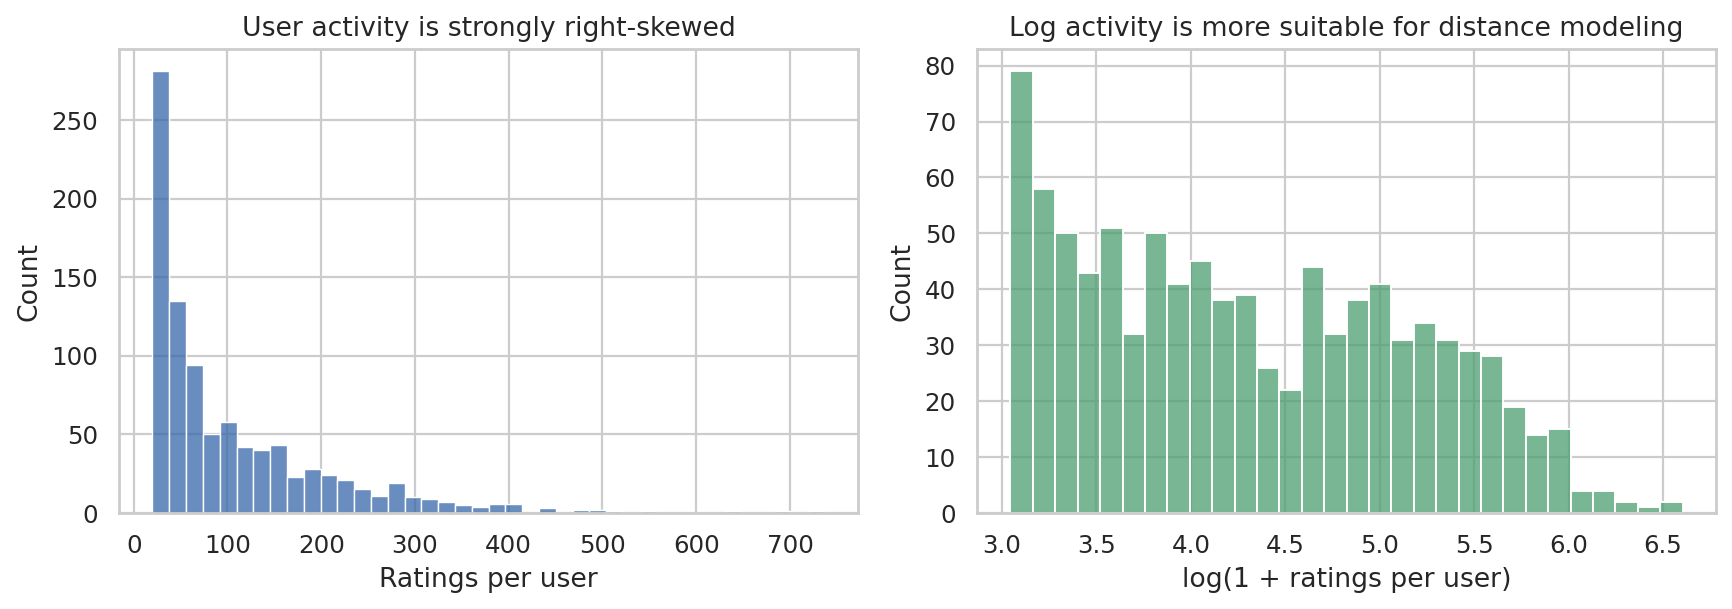

Fig 1. User activity is right-skewed; the log transform is more suitable for distance modeling.


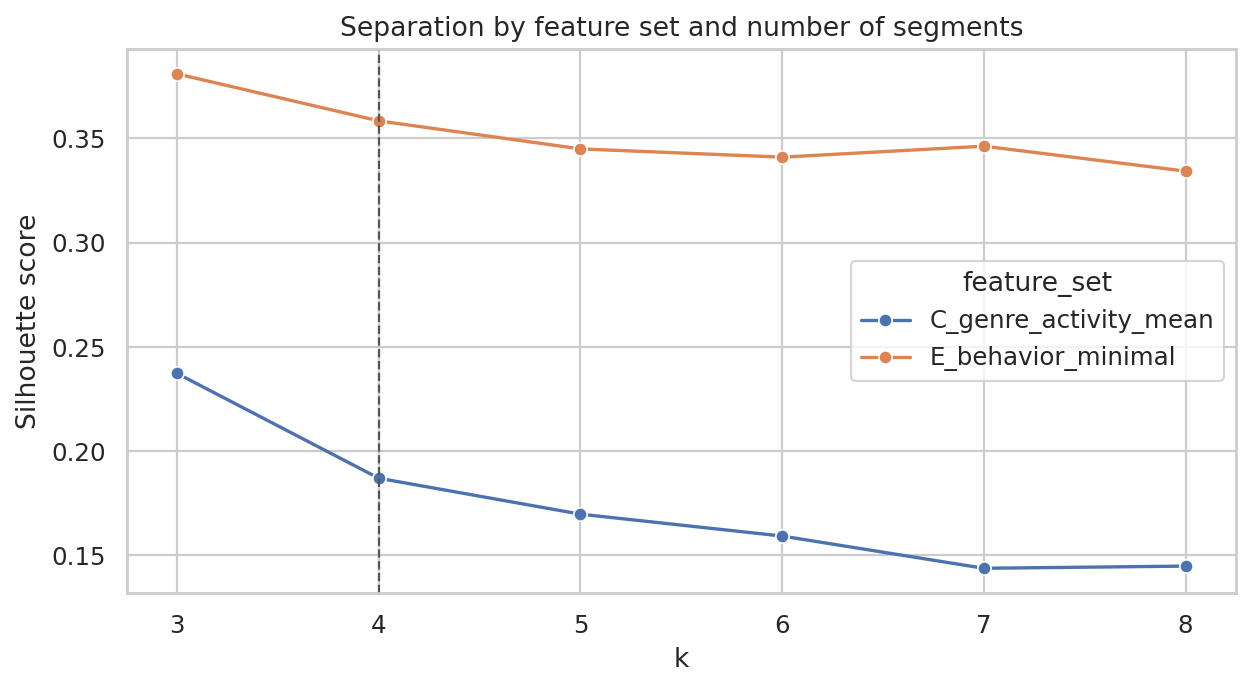

Fig 2. Separation (silhouette) by feature set and number of segments.


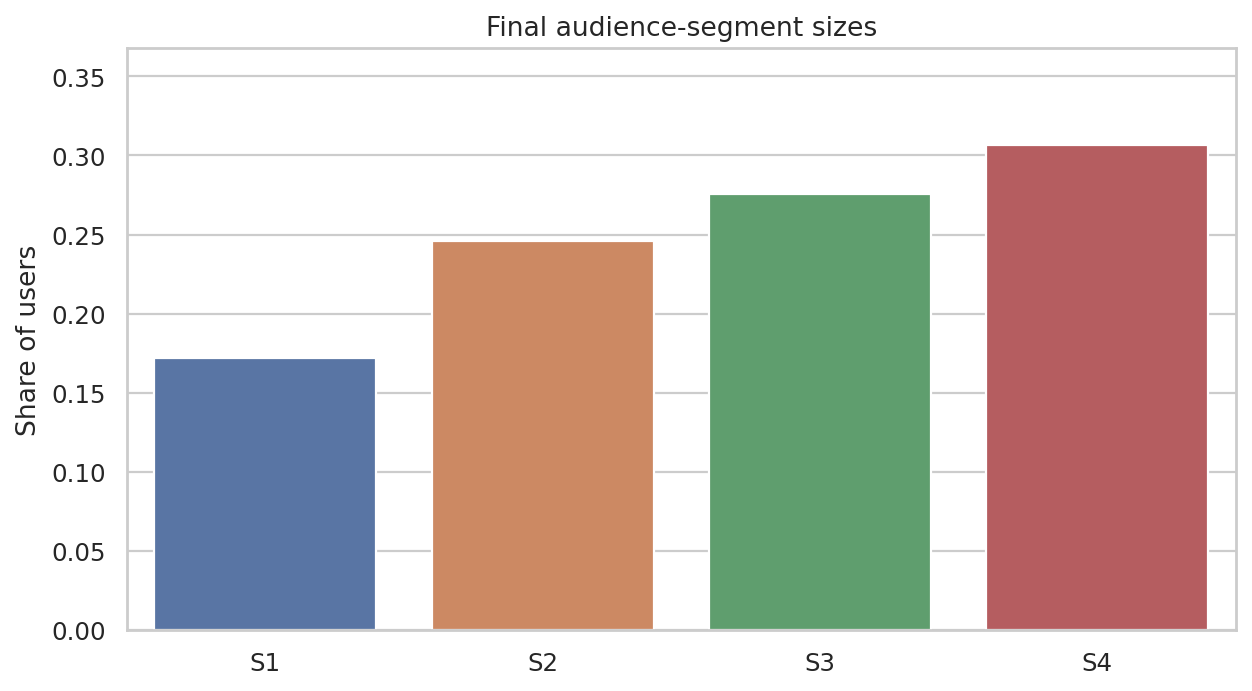

Fig 3. Final audience-segment sizes.


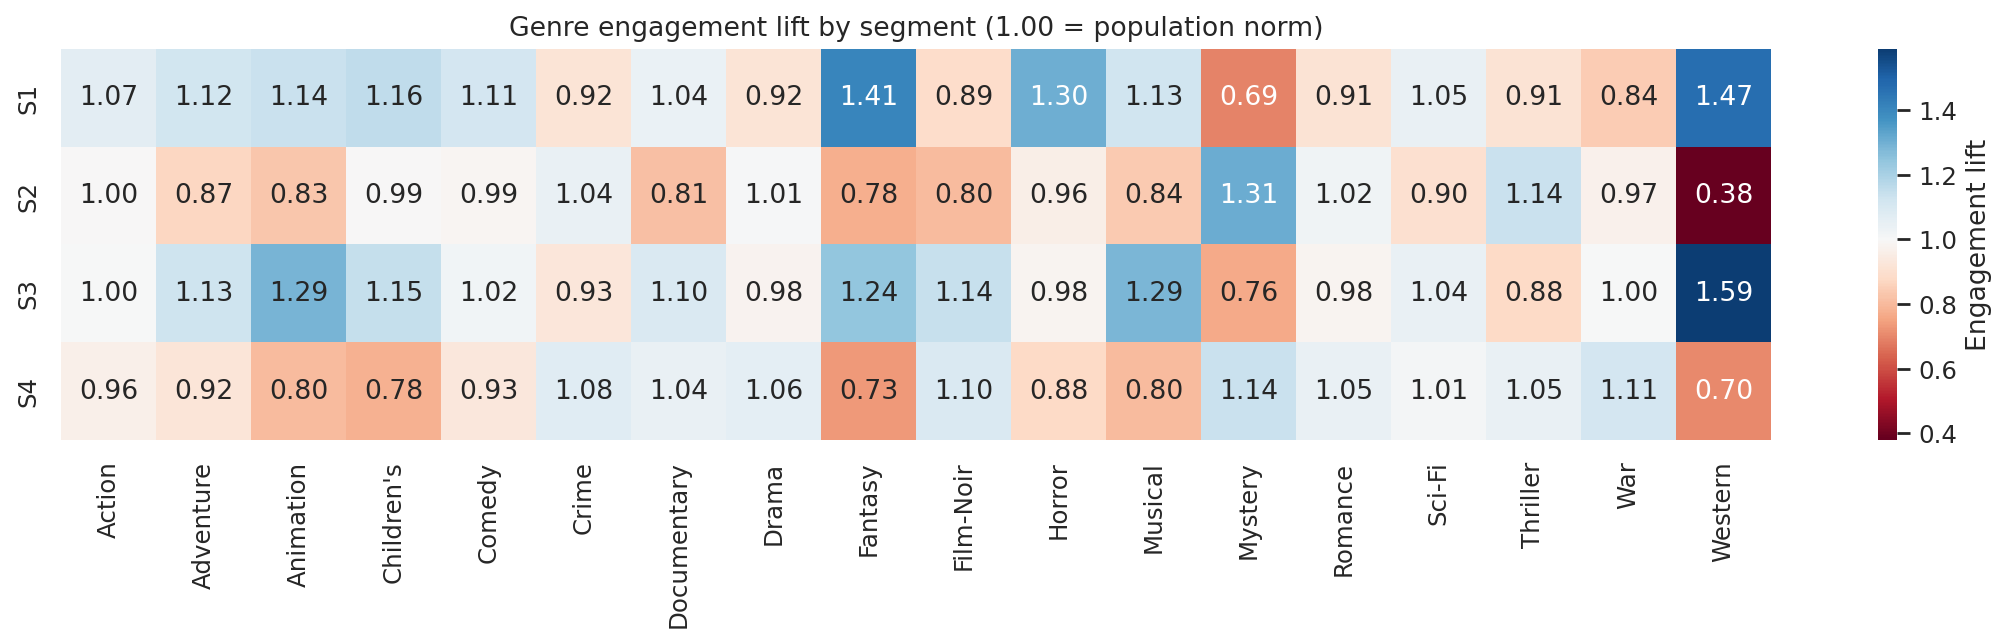

Fig 4. Genre engagement lift by segment (1.00 = population norm).


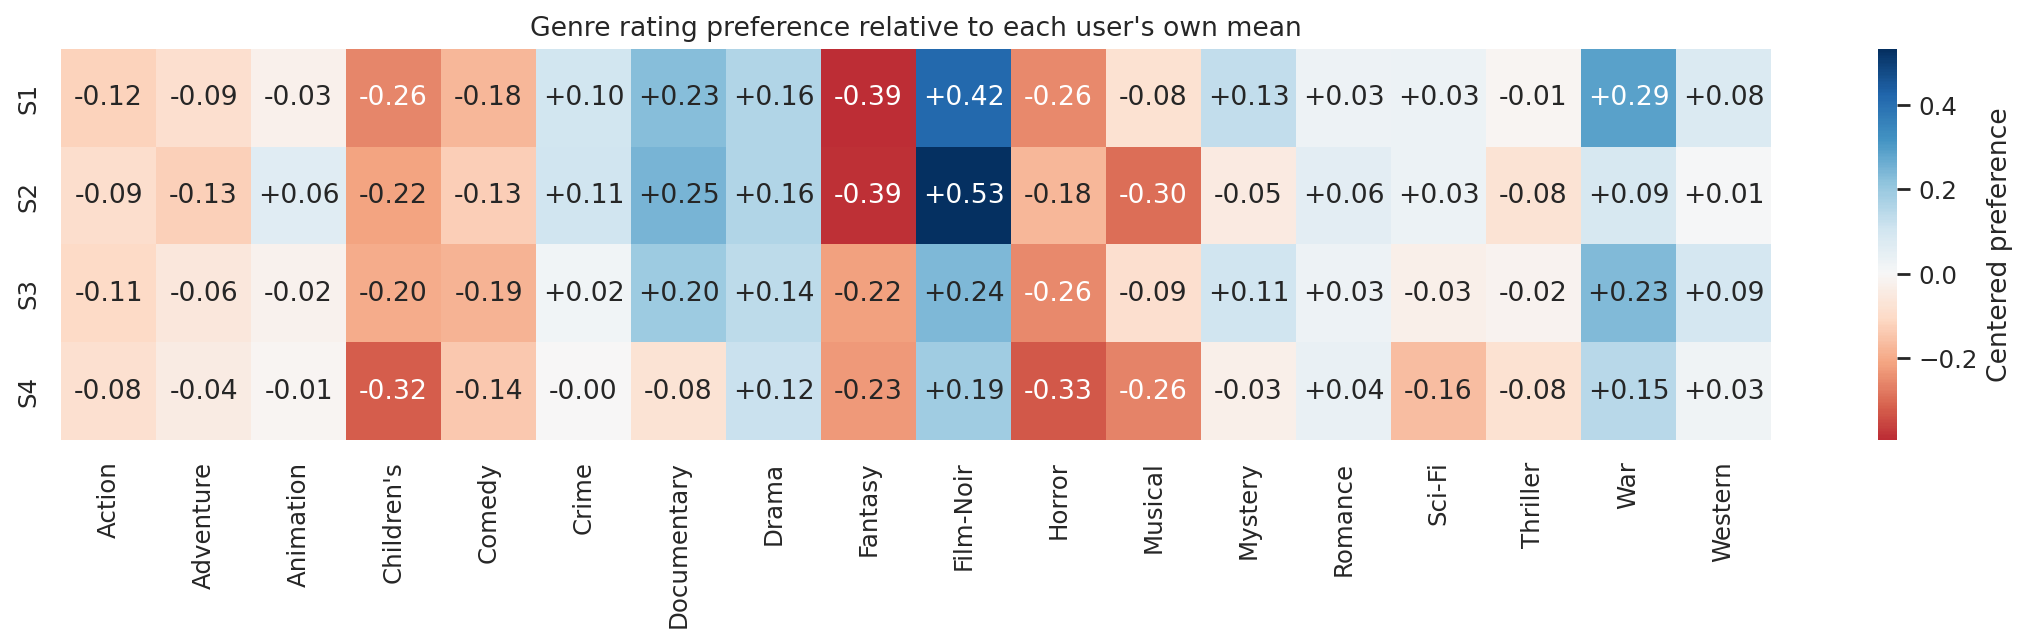

Fig 5. Genre rating preference relative to each user's own mean.


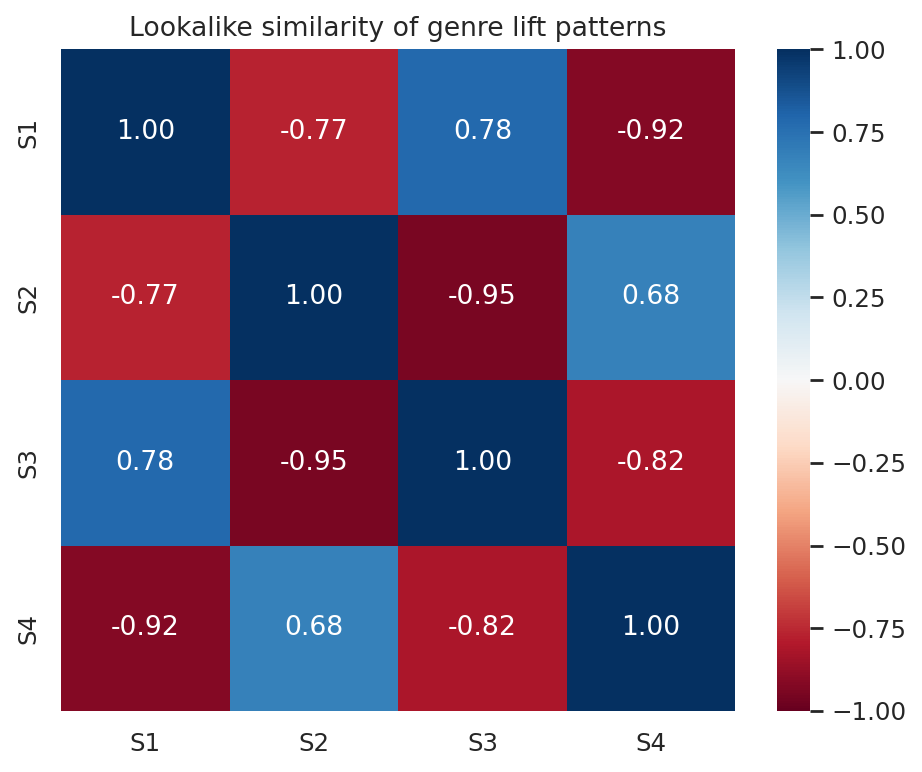

Fig 6. Lookalike similarity of genre-lift patterns across segments.


In [11]:
create_figures(paths)
figure_captions = {
    "01_user_activity_distribution.png": "Fig 1. User activity is right-skewed; the log transform is more suitable for distance modeling.",
    "02_model_selection.png": "Fig 2. Separation (silhouette) by feature set and number of segments.",
    "03_segment_sizes.png": "Fig 3. Final audience-segment sizes.",
    "04_engagement_lift_heatmap.png": "Fig 4. Genre engagement lift by segment (1.00 = population norm).",
    "05_centered_preference_heatmap.png": "Fig 5. Genre rating preference relative to each user's own mean.",
    "06_segment_similarity.png": "Fig 6. Lookalike similarity of genre-lift patterns across segments.",
}
for figure_name, caption in figure_captions.items():
    display(Image(filename=str(paths.figures / figure_name)))
    print(caption)

## 11. Business findings and hypotheses

### Evidence directly supported

- Users separate strongly along rating activity and overall rating tendency.
- Four groups provide a stable, interpretable split while preserving meaningful audience sizes.
- Genre lift and centered preference sometimes disagree, which makes a one-dimensional affinity ranking unsafe.
- Some segments share engagement-profile shapes despite different activity or rating levels, creating potential lookalike hypotheses.

### Hypotheses worth testing

- Use high-support aligned affinities for broad segment-specific creative.
- Use selective appreciation for niche discovery or prestige positioning rather than mass reach.
- Treat engagement-tension genres as diagnostic cohorts: test curation quality, novelty, or adjacent genres.
- Test lookalike transfer only when both the shared genre pattern and campaign objective make sense.

### Claims not supported

- A segment will retain better or churn less.
- Higher ratings cause higher future engagement.
- A lookalike campaign will produce incremental response.
- The four segments are permanent or universal audience identities.

In [12]:
supported = affinity.loc[affinity["genre_user_support_share"].ge(0.20)].copy()
opportunity_view = (
    supported.sort_values(["segment", "engagement_lift"], ascending=[True, False])
    .groupby("segment", as_index=False)
    .head(3)[
        [
            "segment",
            "segment_name",
            "genre",
            "segment_engagement_share",
            "engagement_lift",
            "user_centered_rating_preference",
            "genre_user_support_share",
            "affinity_interpretation",
        ]
    ]
)
display(opportunity_view)

,segment,segment_name,genre,segment_engagement_share,engagement_lift,user_centered_rating_preference,genre_user_support_share,affinity_interpretation
17,S1,Heavy Critics,Western,0.0105,1.4693,0.0798,0.8580,aligned affinity
8,S1,Heavy Critics,Fantasy,0.0043,1.4078,-0.3947,0.9198,high engagement / below personal norm
10,S1,Heavy Critics,Horror,0.0363,1.3048,-0.2557,0.9815,high engagement / below personal norm
30,S2,Casual Critics,Mystery,0.0349,1.3076,-0.0488,0.9353,engagement-led affinity
33,S2,Casual Critics,Thriller,0.1175,1.1396,-0.0764,0.9914,high engagement / below personal norm
23,S2,Casual Critics,Crime,0.0359,1.0430,0.1062,0.9353,satisfaction-led affinity
53,S3,Heavy Enthusiasts,Western,0.0113,1.5896,0.0935,0.8769,aligned affinity
38,S3,Heavy Enthusiasts,Animation,0.0147,1.2877,-0.0249,0.9308,engagement-led affinity
47,S3,Heavy Enthusiasts,Musical,0.0219,1.2855,-0.0886,0.9654,high engagement / below personal norm
66,S4,Casual Enthusiasts,Mystery,0.0303,1.1367,-0.0305,0.8997,engagement-led affinity


## 12. Limitations and future validation

### Data limitations

- Historical ratings are not modern streaming telemetry.
- No watch time, completion, impressions, catalog availability, or marketing exposure exists.
- Rating timestamps are not reliable universal viewing timestamps.
- Multi-genre allocation is a transparent but still simplifying rule.

### Modeling limitations

- K-means creates hard convex groups and can simplify a behavioral continuum.
- Segment names depend on analyst interpretation.
- Assignment margin is not a probability.
- Affinity cutoffs and the 20% support threshold are descriptive reporting choices.

### Next evidence to collect

- Exposure and completion metrics
- Retention or campaign-response outcomes
- Temporal segment migration
- Soft-clustering sensitivity
- Controlled experiments for campaign and recommendation hypotheses

## 13. End-to-end validation

The final check reloads the generated artifacts and verifies the assumptions that matter most: source counts, data grains, feature integrity, segment reconciliation, affinity ranges, and dashboard exports. The pipeline is designed to fail fast if any of these checks break.

In [ ]:
validation_summary = validate_all(paths)
validation_summary